In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.preprocessing import ICA

# Load data
data_path = mne.datasets.sample.data_path()
raw_fif_path = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(raw_fif_path, preload=True)

# Pick EEG only
raw.pick('eeg')

# Apply bandpass filter (Phase 2)
raw.filter(l_freq=0.1, h_freq=40.0)

# Apply ICA to remove eye blinks (Phase 3)
ica = ICA(n_components=15, random_state=42)
ica.fit(raw)
ica.exclude = [0]  # Remove eye blink component
raw = ica.apply(raw)

print("Data loaded, filtered, and cleaned!")
print(f"Channels: {len(raw.ch_names)}, Duration: {raw.times[-1]:.1f} sec")

Opening raw data file /Users/aleksandraszymanska/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 19821 samples (33.001 s)

Fitting ICA to data using 59 channels (please be patient, this may

In [2]:
# Load the events file (comes with the sample data)
events_path = data_path / "MEG" / "sample" / "sample_audvis_raw-eve.fif"
events = mne.read_events(events_path)

# See what we have
print(f"Found {len(events)} events")
print(f"First 10 events:\n{events[:10]}")

Found 320 events
First 10 events:
[[27977     0     2]
 [28345     0     3]
 [28771     0     1]
 [29219     0     4]
 [29652     0     2]
 [30025     0     3]
 [30450     0     1]
 [30839     0     4]
 [31240     0     2]
 [31665     0     3]]


In [5]:
# Define what each event ID means
event_id = {
    'auditory/left': 1,
    'auditory/right': 2,
    'visual/left': 3,
    'visual/right': 4
}

# Count each type (handles unknown events)
unique, counts = np.unique(events[:, 2], return_counts=True)
for event_code, count in zip(unique, counts):
    # Find name if it exists, otherwise call it "unknown"
    name = [k for k, v in event_id.items() if v == event_code]
    name = name[0] if name else "unknown"
    print(f"Event {event_code} ({name}): {count} trials")

Event 1 (auditory/left): 72 trials
Event 2 (auditory/right): 73 trials
Event 3 (visual/left): 73 trials
Event 4 (visual/right): 71 trials
Event 5 (unknown): 15 trials
Event 32 (unknown): 16 trials


In [6]:
# Define epoch parameters
tmin = -0.2  # 200 ms before stimulus
tmax = 0.5   # 500 ms after stimulus

# Create epochs (only for our 4 event types)
epochs = mne.Epochs(
    raw, 
    events, 
    event_id=event_id,  # Only these events
    tmin=tmin, 
    tmax=tmax,
    baseline=(None, 0),  # Baseline correction: subtract mean of pre-stimulus period
    preload=True
)

print(epochs)

Not setting metadata
289 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 289 events and 421 original time points ...
0 bad epochs dropped
<Epochs | 289 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~58.6 MiB, data loaded,
 'auditory/left': 72
 'auditory/right': 73
 'visual/left': 73
 'visual/right': 71>


/var/folders/hy/4bfcl6wj5x9blcjd8wnvrhyr0000gn/T/ipykernel_71512/2697885119.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


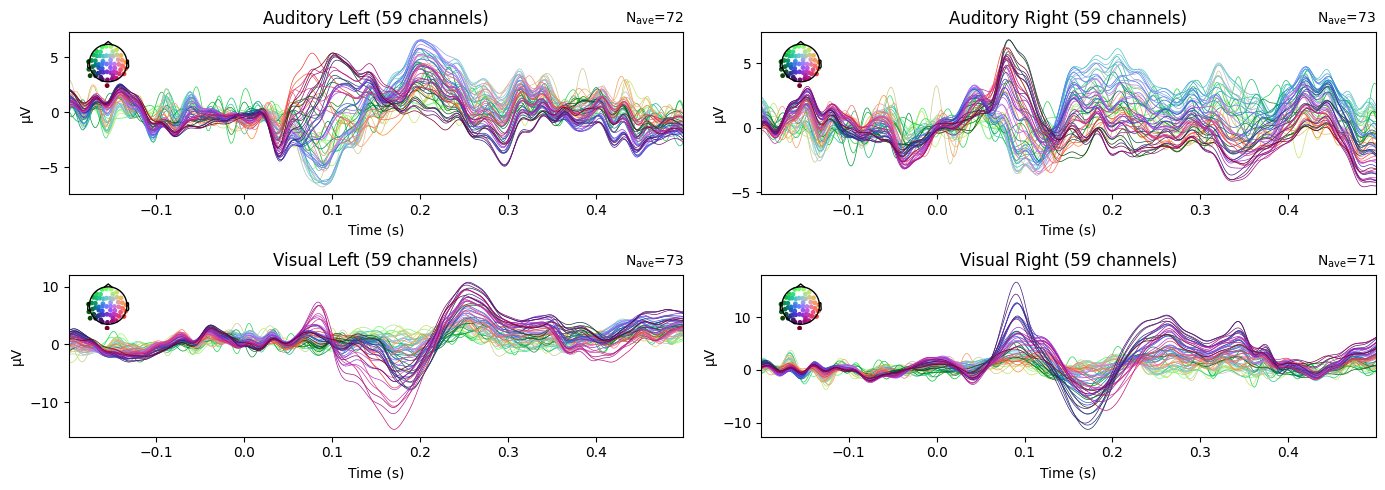

In [13]:
# Average epochs for each condition
erp_auditory_left = epochs['auditory/left'].average()
erp_auditory_right = epochs['auditory/right'].average()
erp_visual_left = epochs['visual/left'].average()
erp_visual_right = epochs['visual/right'].average()

# Plot auditory ERPs
fig, axes = plt.subplots(2, 2, figsize=(14, 5))

erp_auditory_left.plot(axes=axes[0, 0], show=False, titles='Auditory Left')
erp_auditory_right.plot(axes=axes[0, 1], show=False, titles='Auditory Right')
erp_visual_left.plot(axes=axes[1, 0], show=False, titles='Visual Left')
erp_visual_right.plot(axes=axes[1, 1], show=False, titles='Visual Right')

plt.tight_layout()
plt.show()

Need more than one channel to make topography for eeg. Disabling interactivity.


Need more than one channel to make topography for eeg. Disabling interactivity.
Need more than one channel to make topography for eeg. Disabling interactivity.
Need more than one channel to make topography for eeg. Disabling interactivity.


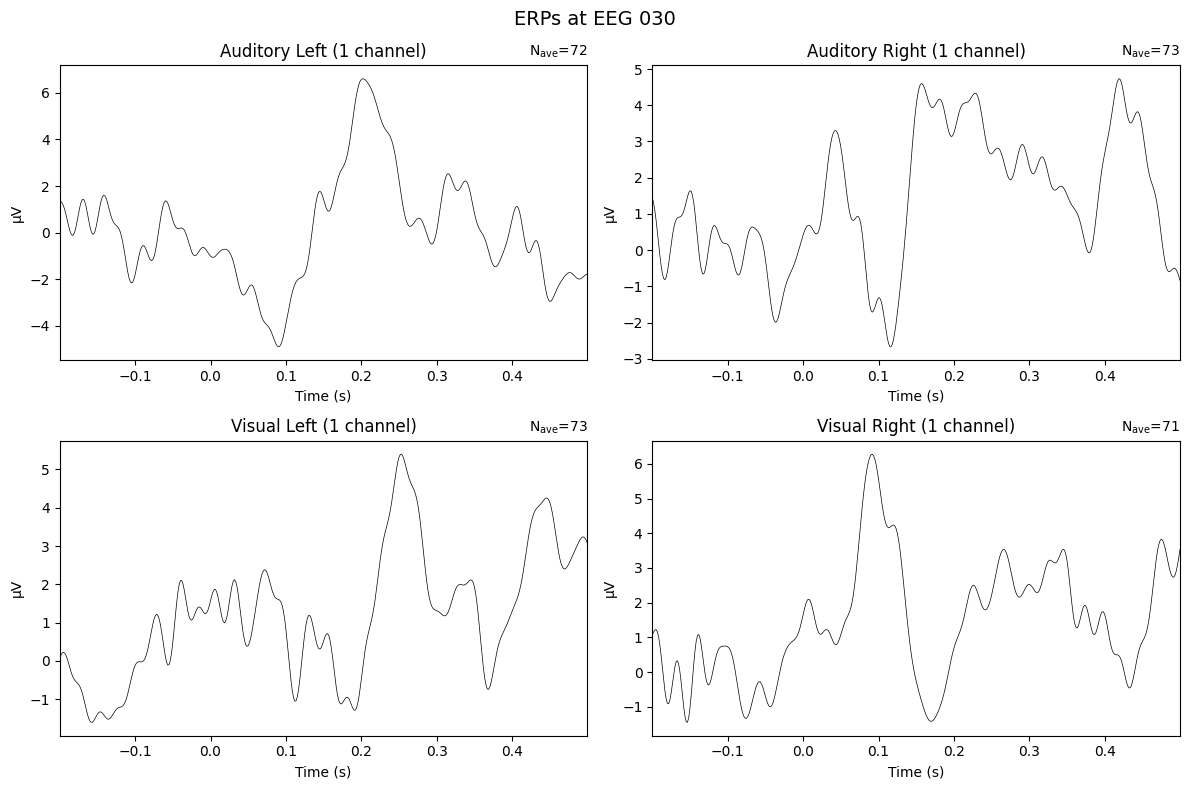

In [14]:
# Pick a central channel to compare all conditions
channel = 'EEG 030'  # Central electrode

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot each condition
erp_auditory_left.plot(picks=[channel], axes=axes[0, 0], show=False, titles='Auditory Left')
erp_auditory_right.plot(picks=[channel], axes=axes[0, 1], show=False, titles='Auditory Right')
erp_visual_left.plot(picks=[channel], axes=axes[1, 0], show=False, titles='Visual Left')
erp_visual_right.plot(picks=[channel], axes=axes[1, 1], show=False, titles='Visual Right')

plt.suptitle(f'ERPs at {channel}', fontsize=14)
plt.tight_layout()
plt.show()

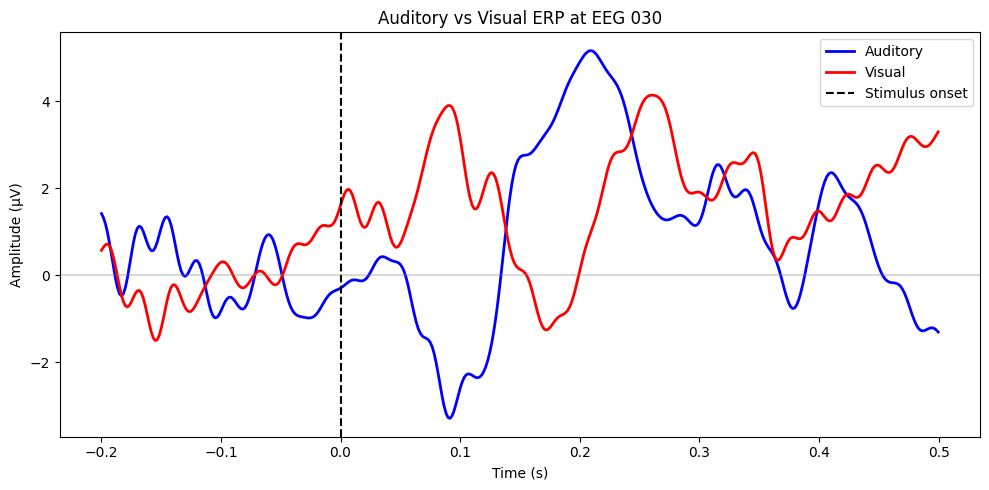

In [15]:
# Combine left+right for each modality
erp_auditory = epochs['auditory/left', 'auditory/right'].average()
erp_visual = epochs['visual/left', 'visual/right'].average()

# Plot comparison at one channel
channel = 'EEG 030'

fig, ax = plt.subplots(figsize=(10, 5))

# Get data for plotting
times = erp_auditory.times
aud_data = erp_auditory.copy().pick([channel]).get_data()[0] * 1e6
vis_data = erp_visual.copy().pick([channel]).get_data()[0] * 1e6

ax.plot(times, aud_data, label='Auditory', color='blue', linewidth=2)
ax.plot(times, vis_data, label='Visual', color='red', linewidth=2)
ax.axvline(0, color='black', linestyle='--', label='Stimulus onset')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title(f'Auditory vs Visual ERP at {channel}')
ax.legend()

plt.tight_layout()
plt.show()